# Linking dwellings to buildings

Observed EPCs join to footprints by UPRN. Missing-dwelling records are placed in available address slots, giving each completed dwelling a UPRN and building TOID.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200); pd.set_option('display.max_columns', 60)

ROOT = Path('..')
DATA = Path('data')
OUT  = Path('output'); OUT.mkdir(exist_ok=True)

BUILDINGS = ROOT / 'dATA' / 'guildford_buildings.gpkg'
LSOA_SHP  = ROOT / 'guildford_LSOA' / 'guildford_lsoas.shp'
EPC_CLEAN = ROOT / 'processed_epc_data_clean.csv'
STOCK     = OUT / 'guildford_stock_complete.parquet'

AREA_MIN, AREA_MAX = 12, 500
KEEP_IF_HAS_UPRN = True
SEED = 42

FEATURES = ['accommodation_type', 'Heat system', 'wall_construction', 'wall_insulation',
            'glazing_type', 'roof_type', 'TENURE', 'age_band']

## 4.1 Buildings, filtered and given an LSOA

In [2]:
bld = gpd.read_file(BUILDINGS).to_crs(27700)
print(f'{len(bld):,} buildings read')
print(bld['use_class_final'].value_counts().to_string())

outside = (bld['area_m2'] < AREA_MIN) | (bld['area_m2'] > AREA_MAX)
has_uprn = bld['uprn_count'].fillna(0) > 0
drop = outside & ~has_uprn if KEEP_IF_HAS_UPRN else outside
bld = bld[~drop].copy().reset_index(drop=True)
print(f'\nsize filter {AREA_MIN}-{AREA_MAX} m2, sparing anything with a UPRN')
print(f'  dropped {int(drop.sum()):,} -> {len(bld):,} retained')

lsoa_poly = gpd.read_file(LSOA_SHP).to_crs(27700)
cen = gpd.GeoDataFrame(bld[['toid']].copy(), geometry=bld.geometry.centroid, crs=27700)
j = gpd.sjoin(cen, lsoa_poly[['LSOA', 'geometry']], how='left', predicate='within')
j = j[['toid', 'LSOA']].drop_duplicates('toid')
miss = j['LSOA'].isna()
if miss.any():
    near = gpd.sjoin_nearest(cen[cen['toid'].isin(j.loc[miss, 'toid'])],
                             lsoa_poly[['LSOA', 'geometry']], how='left')
    near = near[['toid', 'LSOA']].drop_duplicates('toid').set_index('toid')['LSOA']
    j.loc[miss, 'LSOA'] = j.loc[miss, 'toid'].map(near)
    print(f'  {int(miss.sum()):,} edge buildings given their nearest LSOA')

bld = bld.merge(j, on='toid', how='left')
bld['centroid_x'] = bld.geometry.centroid.x
bld['centroid_y'] = bld.geometry.centroid.y
_ll = gpd.GeoSeries(bld.geometry.centroid, crs=27700).to_crs(4326)
bld['lon'], bld['lat'] = _ll.x.values, _ll.y.values
print(f'  LSOA assigned to {bld["LSOA"].notna().sum():,} / {len(bld):,}')

LOCAL_PATH/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


  LSOA assigned to 58,630 / 58,630


## 4.2 The UPRN slot table

`uprn_list` here comes from the OS TOID↔UPRN linkage, so each UPRN belongs to exactly one
building. The assertion below is what makes the rest of the notebook safe — if a UPRN could
appear on two buildings, every count downstream would double.

In [3]:
ul = bld['uprn_list'].astype('string').fillna('')
slots = (bld.loc[ul.str.strip() != '', ['toid', 'uprn_list']]
         .assign(UPRN=lambda d: d['uprn_list'].astype('string').str.split(';')).explode('UPRN'))
slots['UPRN'] = slots['UPRN'].str.strip()
slots = slots[slots['UPRN'].str.fullmatch(r'\d+', na=False)][['UPRN', 'toid']]

assert not slots['UPRN'].duplicated().any(), 'a UPRN maps to more than one building'
slots = slots.merge(bld[['toid', 'LSOA', 'dwelling_type', 'use_class_final']], on='toid', how='left')

DT_TO_ACC = {'Detached house': 'Detached', 'Semi-detached house': 'Semi-detached',
             'Terraced house': 'Terraced', 'Flats': 'Flat'}
slots['form'] = slots['dwelling_type'].map(DT_TO_ACC)

print(f'{len(slots):,} UPRN slots across {slots["toid"].nunique():,} buildings')
print('every UPRN on exactly one building: OK')
print()
print(slots['form'].fillna('(untyped)').value_counts().to_string())

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## 4.3 Attach the observed EPCs

A straight join on UPRN. Nothing is inferred here — the UPRN either is in a building's list or
it isn't.

In [4]:
epc = pd.read_csv(EPC_CLEAN, dtype={'UPRN': str})
uprn_lsoa = pd.read_parquet(DATA / 'uprn_lsoa_spatial.parquet')
epc = epc.merge(uprn_lsoa.rename(columns={'LSOA': '_sp'}), on='UPRN', how='left')
epc['LSOA'] = epc['_sp'].fillna(epc['LSOA'])
epc = epc[epc['LSOA'].notna()].drop(columns='_sp').reset_index(drop=True)
print(f'observed EPC dwellings: {len(epc):,}')

epc = epc.merge(slots[['UPRN', 'toid']], on='UPRN', how='left')
placed = epc['toid'].notna()
print(f'  placed on a building : {placed.sum():,} ({100*placed.mean():.1f}%)')
print(f'  no building          : {(~placed).sum():,}')

print()
print('where the placed ones sit, by building use class:')
print(epc.loc[placed].merge(bld[['toid', 'use_class_final']], on='toid')['use_class_final']
      .value_counts().to_string())

observed EPC dwellings: 40,903


  placed on a building : 40,807 (99.8%)
  no building          : 96

where the placed ones sit, by building use class:
use_class_final
Residential        38619
Non-residential     2188


## 4.4 Place generated records

Generated attribute sets are assigned to available UPRN addresses within the relevant area. The address and building link are real; fabric and heating attributes remain estimates. Unused address slots are left empty.


In [5]:
stock = pd.read_parquet(STOCK)
syn = stock[stock['is_synthetic']].copy()
print(f'imputed dwellings to place: {len(syn):,}')

filled = set(epc.loc[placed, 'UPRN'])
free = slots[~slots['UPRN'].isin(filled)].copy()
print(f'empty UPRN slots          : {len(free):,}')
print()
print('empty slots by building form:')
print(free['form'].fillna('(untyped)').value_counts().to_string())
print()
print('imputed demand by accommodation type:')
print(syn['accommodation_type'].value_counts().to_string())

imputed dwellings to place: 16,493


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


In [6]:
# Allocate: same LSOA + matching building form first, then same LSOA any form.
rng = np.random.default_rng(SEED)
free = free.sample(frac=1.0, random_state=SEED)
syn = syn.sample(frac=1.0, random_state=SEED)

assign = {}
used = set()
for lsoa_code, dg in syn.groupby('LSOA', sort=False):
    pool = free[(free['LSOA'] == lsoa_code) & (~free.index.isin(used))]
    if pool.empty:
        continue
    by_form = {f: list(g.index) for f, g in pool.groupby('form', dropna=True)}
    untyped = [i for i in pool.index if pd.isna(free.at[i, 'form'])]

    leftover = []
    for acc, sub in dg.groupby('accommodation_type', sort=False):
        avail = by_form.get(acc, [])
        take = min(len(sub), len(avail))
        for did, si in zip(sub['dwelling_id'].iloc[:take], avail[:take]):
            assign[did] = (free.at[si, 'UPRN'], free.at[si, 'toid'], True); used.add(si)
        by_form[acc] = avail[take:]
        leftover.extend(sub['dwelling_id'].iloc[take:].tolist())

    rest = [i for i in untyped + [i for v in by_form.values() for i in v] if i not in used]
    for did, si in zip(leftover, rest):
        assign[did] = (free.at[si, 'UPRN'], free.at[si, 'toid'], False); used.add(si)

print(f'placed {len(assign):,} of {len(syn):,} imputed dwellings '
      f'({100*len(assign)/len(syn):.2f}%)')
nform = sum(1 for v in assign.values() if v[2])
print(f'  building form matches   : {nform:,}')
print(f'  form mismatch           : {len(assign)-nform:,}')
print(f'  unplaced                : {len(syn)-len(assign):,}')

placed 16,493 of 16,493 imputed dwellings (100.00%)
  building form matches   : 15,248
  form mismatch           : 1,245
  unplaced                : 0


## 4.5 Assemble one table of every dwelling

In [7]:
obs = epc.copy()
obs['attributes_observed'] = True
obs['form_match'] = True
obs['link_method'] = np.where(obs['toid'].notna(), 'uprn_exact', 'unplaced')

syn2 = syn.copy()
syn2['UPRN']  = syn2['dwelling_id'].map({k: v[0] for k, v in assign.items()})
syn2['toid']  = syn2['dwelling_id'].map({k: v[1] for k, v in assign.items()})
syn2['form_match'] = syn2['dwelling_id'].map({k: v[2] for k, v in assign.items()})
syn2['attributes_observed'] = False
syn2['link_method'] = np.where(
    syn2['toid'].isna(), 'unplaced',
    np.where(syn2['form_match'].fillna(False), 'allocated_form', 'allocated_any'))

keep = FEATURES + ['LSOA', 'UPRN', 'toid', 'attributes_observed', 'form_match', 'link_method']
dwell = pd.concat([obs.reindex(columns=keep), syn2.reindex(columns=keep)], ignore_index=True)
dwell.insert(0, 'dwelling_id', np.arange(1, len(dwell) + 1))
dwell['located'] = dwell['toid'].notna()

print(f'{len(dwell):,} dwellings')
print(dwell['link_method'].value_counts().to_string())
print()
print(f'located          : {dwell["located"].sum():,} ({100*dwell["located"].mean():.2f}%)')
print(f'with a real UPRN : {dwell["UPRN"].notna().sum():,} '
      f'({100*dwell["UPRN"].notna().mean():.2f}%)')
u = dwell['UPRN'].dropna()
assert u.is_unique, 'UPRN duplicated across dwellings'
assert not u.astype(str).str.contains('E', case=False, regex=False).any()
print('UPRN unique and uncorrupted: OK')

[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


## 4.6 Attach the building geometry

In [8]:
GEO = ['toid', 'area_m2', 'height_eaves_m', 'height_ridge_m', 'storeys_est', 'volume_m3',
       'is_flat_roof', 'built_form', 'dwelling_type', 'use_class_final', 'uprn_count',
       'LSOA', 'centroid_x', 'centroid_y', 'lon', 'lat']
full = dwell.merge(bld[GEO].rename(columns={'LSOA': 'LSOA_building'}), on='toid', how='left')

full['dwelling_floor_area_est'] = (
    full['area_m2'] * full['storeys_est'].fillna(1) / full['uprn_count'].clip(lower=1)).round(1)

print(f'{len(full):,} dwellings x {full.shape[1]} columns')
loc = full[full['located']]
print()
print('geometry coverage among located dwellings:')
for c in ['area_m2', 'height_ridge_m', 'storeys_est', 'volume_m3', 'dwelling_floor_area_est']:
    print(f'  {c:<26} {loc[c].notna().sum():>7,} ({100*loc[c].notna().mean():.1f}%)')
print()
print('estimated floor area by accommodation type (m2):')
print(loc.groupby('accommodation_type')['dwelling_floor_area_est']
      .describe(percentiles=[.5])[['count', 'mean', '50%']].round(1).to_string())

57,396 dwellings x 32 columns

geometry coverage among located dwellings:
  area_m2                     57,300 (100.0%)
  height_ridge_m              56,693 (98.9%)
  storeys_est                 56,323 (98.3%)
  volume_m3                   56,323 (98.3%)
  dwelling_floor_area_est     57,300 (100.0%)

estimated floor area by accommodation type (m2):
                      count   mean    50%
accommodation_type                       
Caravan or mobile     461.0  298.8   82.6
Detached            18699.0  187.7  162.1
Flat                11621.0   63.7   56.1
Semi-detached       18243.0  115.8  100.8
Terraced             8175.0   93.6   89.1
Unknown               101.0  144.2  110.2


In [9]:
# Sanity: does the estimate agree with the measured EPC floor area?
raw = pd.read_csv(ROOT / 'guildford_raw_certificates.csv',
                  usecols=['uprn', 'total_floor_area', 'inspection_date'],
                  dtype={'uprn': 'string'}, low_memory=False)
raw = (raw.dropna(subset=['uprn'])
       .sort_values('inspection_date').drop_duplicates('uprn', keep='last')
       .rename(columns={'uprn': 'UPRN', 'total_floor_area': 'epc_floor_area'}))
chk = loc.merge(raw[['UPRN', 'epc_floor_area']], on='UPRN', how='inner')
chk = chk[(chk['epc_floor_area'] > 10) & (chk['epc_floor_area'] < 1000)]
chk['ratio'] = chk['dwelling_floor_area_est'] / chk['epc_floor_area']
print(f'{len(chk):,} dwellings have both a measured and an estimated floor area')
print()
print(chk.groupby('accommodation_type')['ratio']
      .describe(percentiles=[.25, .5, .75])[['count', '25%', '50%', '75%']].round(2).to_string())
print()
print('ratio = estimate / measured. 1.0 is perfect; >1 means the estimate is too big')
print('(expected: footprint x storeys ignores internal walls, stairs and roof pitch)')

40,799 dwellings have both a measured and an estimated floor area

                      count   25%   50%   75%
accommodation_type                           
Caravan or mobile      69.0  1.05  1.09  1.16
Detached            10789.0  0.85  1.20  1.46
Flat                10861.0  0.78  1.08  1.30
Semi-detached       11846.0  0.90  1.17  1.35
Terraced             7133.0  1.01  1.17  1.31
Unknown               101.0  0.92  1.14  1.18

ratio = estimate / measured. 1.0 is perfect; >1 means the estimate is too big
(expected: footprint x storeys ignores internal walls, stairs and roof pitch)


## 4.7 Building-level view, and export

In [10]:
def safe_mode(s):
    """Most common non-null value; None if the group is entirely null."""
    s = s.dropna()
    return s.value_counts().idxmax() if len(s) else None


per_b = (loc.groupby('toid')
         .agg(n_dwellings=('dwelling_id', 'count'),
              n_observed=('attributes_observed', 'sum'),
              accommodation_type=('accommodation_type', safe_mode),
              heat_system=('Heat system', safe_mode),
              wall_insulation=('wall_insulation', safe_mode),
              age_band=('age_band', safe_mode))
         .reset_index())
per_b['n_imputed'] = per_b['n_dwellings'] - per_b['n_observed']

buildings = bld.merge(per_b, on='toid', how='left')
buildings['n_dwellings'] = buildings['n_dwellings'].fillna(0).astype(int)
buildings['has_dwelling'] = buildings['n_dwellings'] > 0

print(f'buildings                : {len(buildings):,}')
print(f'  with >=1 dwelling      : {buildings["has_dwelling"].sum():,} '
      f'({100*buildings["has_dwelling"].mean():.1f}%)')
print(f'  multi-dwelling         : {(buildings["n_dwellings"]>1).sum():,}')
print(f'dwellings placed         : {buildings["n_dwellings"].sum():,}')

buildings                : 58,630
  with >=1 dwelling      : 47,370 (80.8%)
  multi-dwelling         : 3,540
dwellings placed         : 57,300


In [11]:
out_pq   = OUT / 'guildford_dwellings_final.parquet'
out_csv  = OUT / 'guildford_dwellings_final.csv'
out_gpkg = OUT / 'guildford_buildings_final.gpkg'

full.to_parquet(out_pq, index=False)
full.to_csv(out_csv, index=False)
buildings.to_file(out_gpkg, driver='GPKG')

print('wrote:')
for p in (out_pq, out_csv, out_gpkg):
    print(f'  {p}  ({p.stat().st_size/1e6:.1f} MB)')
print()
print('COLUMNS:')
for i, c in enumerate(full.columns, 1):
    print(f'  {i:>2}. {c}')

LOCAL_PATH/raw.py:723: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


[Review copy: address-level or identifier-bearing output omitted; calculation code is retained.]


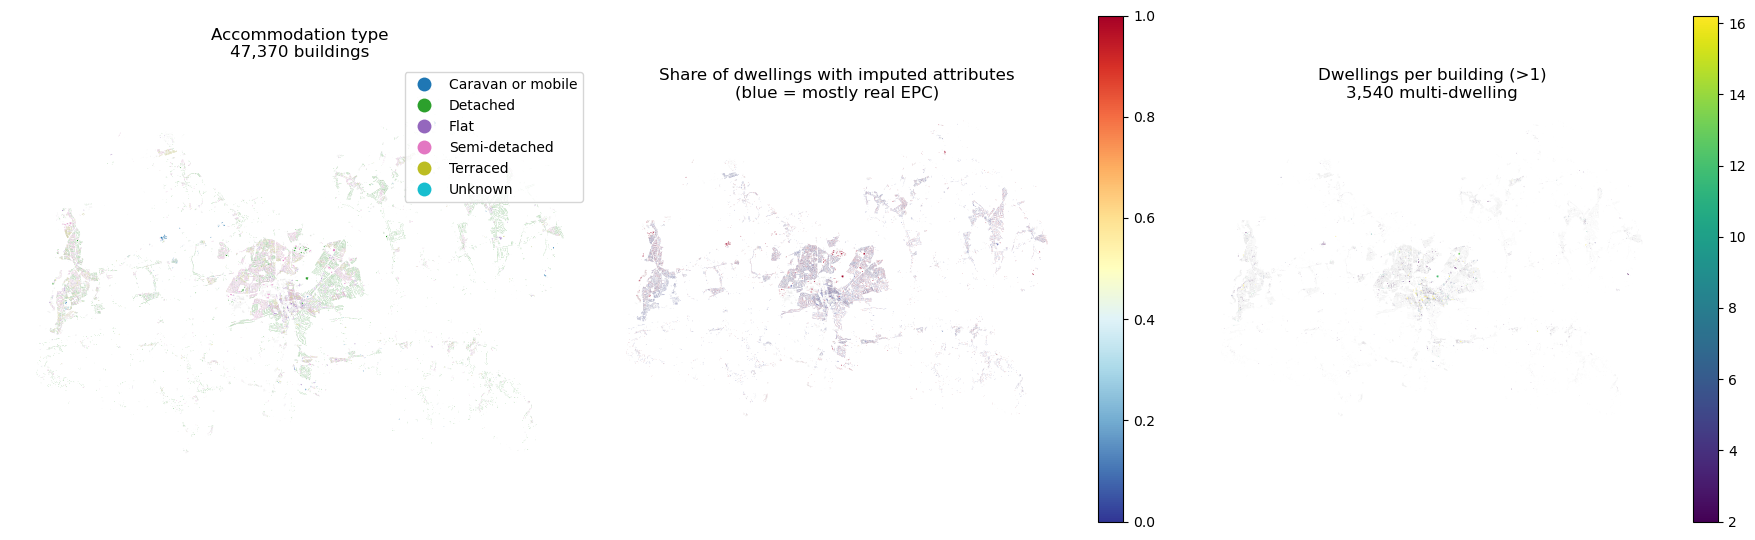

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

buildings.plot(ax=axes[0], color='#ececec', linewidth=0)
buildings[buildings['has_dwelling']].plot(ax=axes[0], column='accommodation_type',
                                          categorical=True, legend=True, cmap='tab10', linewidth=0)
axes[0].set_title(f'Accommodation type\n{buildings["has_dwelling"].sum():,} buildings')
axes[0].set_axis_off()

buildings['imputed_share'] = (buildings['n_imputed'] /
                              buildings['n_dwellings'].replace(0, np.nan))
buildings.plot(ax=axes[1], color='#ececec', linewidth=0)
buildings[buildings['imputed_share'].notna()].plot(
    ax=axes[1], column='imputed_share', legend=True, cmap='RdYlBu_r', linewidth=0)
axes[1].set_title('Share of dwellings with imputed attributes\n(blue = mostly real EPC)')
axes[1].set_axis_off()

m = buildings['n_dwellings'] > 1
buildings.plot(ax=axes[2], color='#ececec', linewidth=0)
buildings[m].plot(ax=axes[2], column='n_dwellings', legend=True, cmap='viridis',
                  linewidth=0, vmax=buildings.loc[m, 'n_dwellings'].quantile(0.98))
axes[2].set_title(f'Dwellings per building (>1)\n{m.sum():,} multi-dwelling')
axes[2].set_axis_off()

plt.tight_layout(); plt.show()

## Linked dwelling stock

The final table carries UPRN and TOID links. `attributes_observed` distinguishes EPC attributes from generated ones, and `link_method` records how each address was matched. Check `located` for records without a footprint.
